# Joint PLN + MLN FDC-SIV Decay Analysis

This notebook is the manuscript companion for the joint PLN/MLN decay analysis. It reproduces the analyses described in the manuscript: the primary linear mixed-effects (LME) model, Table 1, model comparisons for the nested alternatives, diagnostics, Figure 4B, and two compact robustness checks.

Here, **LME** means **linear mixed-effects**.


## Environment

Required packages: `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib`, and `ipykernel`.

If needed, run the optional setup cell below once in the notebook kernel. The version-report cell records the runtime used for reproducibility. In a `uv` workflow, run the notebook from an environment containing the same packages listed here.


In [1]:
# Optional setup cell. Run only if dependencies are missing.
# %pip install numpy pandas scipy statsmodels matplotlib ipykernel


In [2]:
import sys
import numpy as np
import pandas as pd
import scipy
import statsmodels
import matplotlib
import ipykernel

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("matplotlib:", matplotlib.__version__)
print("ipykernel:", ipykernel.__version__)


Python: 3.13.12 (main, Feb 12 2026, 01:06:02) [Clang 21.1.4 ]
numpy: 2.4.6
pandas: 3.0.3
scipy: 1.17.1
statsmodels: 0.14.6
matplotlib: 3.10.9
ipykernel: 7.2.0


## Data

The data are FDC-associated SIV viral loads measured in PLN and MLN samples from 15 animals: 6 controls and 9 anti-CD21-treated animals. Each animal contributes 9 measurements: PLN at days 0, 7, 14, 28, and 42 after ART initiation, and MLN at days 0, 14, 28, and 42 after ART initiation.


In [3]:
import numpy as np
import pandas as pd

V_PLN = np.array([[22122.1, 17750.2, 3923.2, 1213.1, 531.0], [25610.5, 15946.7, 10655.1, 7507.8, 570.8], [32669.2, 17730.1, 6797.2, 1915.6, 905.4], [25864.8, 22364.4, 4706.2, 1871.5, 1115.0], [7501.1, 1669.0, 555.7, 104.9, 27.3], [40060.5, 17477.2, 2210.5, 772.4, 353.0], [11958.0, 2655.4, 974.0, 24.9, 6.5], [14976.9, 9506.3, 952.9, 209.5, 8.8], [14637.9, 8192.5, 805.5, 102.1, 38.2], [33158.1, 25461.8, 14432.9, 4913.9, 3830.4], [35269.3, 34968.9, 5029.9, 751.8, 66.7], [55576.9, 26658.7, 2406.6, 1388.0, 547.5], [36596.8, 6693.0, 11987.0, 1021.7, 105.0], [22339.4, 5209.4, 1266.3, 1244.8, 66.2], [2512.3, 731.8, 199.3, 97.1, 7.7]], dtype=float)
V_MLN = np.array([[77050.2, 19810.4, 3919.0, 2343.8], [33763.0, 6272.7, 913.3, 664.8], [48107.9, 14315.7, 500.9, 366.7], [47953.5, 9410.7, 581.3, 1022.7], [16717.9, 3207.7, 60.8, 499.3], [24390.3, 9309.7, 414.0, 259.8], [39431.1, 4894.9, 104.9, 156.2], [24869.4, 2173.7, 222.3, 152.0], [18216.1, 941.6, 259.1, 63.3], [41394.4, 16744.1, 3410.7, 281.5], [77237.4, 23773.1, 4485.3, 3655.4], [90722.3, 16493.0, 1411.1, 572.9], [19469.4, 992.2, 213.0, 130.5], [29487.8, 1531.5, 122.2, 78.2], [1107.6, 46.1, 29.8, 21.0]], dtype=float)

times_pln_days = np.array([0, 7, 14, 28, 42], dtype=float)
times_mln_days = np.array([0, 14, 28, 42], dtype=float)

CONTROL_IDS = [33982, 34319, 34902, 35531, 35621, 36451]
TREATED_IDS = [32891, 33638, 34598, 35263, 35499, 35613, 35650, 36716, 36897]
ANIMAL_IDS = CONTROL_IDS + TREATED_IDS
LN10 = np.log(10.0)

rows = []
for i, aid in enumerate(ANIMAL_IDS):
    treatment = "ART only" if aid in CONTROL_IDS else "ART + anti-CD21"
    for j, t in enumerate(times_pln_days):
        rows.append({
            "animal_id": str(aid),
            "treatment": treatment,
            "tissue": "PLN",
            "time_days": float(t),
            "time_weeks": float(t) / 7.0,
            "vl": float(V_PLN[i, j]),
        })
    for j, t in enumerate(times_mln_days):
        rows.append({
            "animal_id": str(aid),
            "treatment": treatment,
            "tissue": "MLN",
            "time_days": float(t),
            "time_weeks": float(t) / 7.0,
            "vl": float(V_MLN[i, j]),
        })

df = pd.DataFrame(rows)
df["v_log10"] = np.log10(df["vl"])
df["treated_flag"] = (df["treatment"] == "ART + anti-CD21").astype(int)
df["scaled_time"] = -df["time_days"] / LN10

print("PLN shape:", V_PLN.shape, "times:", times_pln_days)
print("MLN shape:", V_MLN.shape, "times:", times_mln_days)
print("Rows:", len(df), "Animals:", df["animal_id"].nunique())
display(df.head())


PLN shape: (15, 5) times: [ 0.  7. 14. 28. 42.]
MLN shape: (15, 4) times: [ 0. 14. 28. 42.]
Rows: 135 Animals: 15


,animal_id,treatment,tissue,time_days,time_weeks,vl,v_log10,treated_flag,scaled_time
0,33982,ART only,PLN,0.0,0.0,22122.1,4.344826,0,-0.000000
1,33982,ART only,PLN,7.0,1.0,17750.2,4.249203,0,-3.040061
2,33982,ART only,PLN,14.0,2.0,3923.2,3.593640,0,-6.080123
3,33982,ART only,PLN,28.0,4.0,1213.1,3.083897,0,-12.160245
4,33982,ART only,PLN,42.0,6.0,531.0,2.725095,0,-18.240368


## Primary Linear Mixed-Effects Model

The manuscript's primary model is

$$
v_{ik} = v_0 + (c_C + I_i\Delta c)x_k + b_i + \varepsilon_{ik},
$$

where $v_{ik}=\log_{10}(V_{ik})$, $x_k=-t_k/\ln(10)$, $c_C$ is the control-arm decay constant, and $\Delta c$ is the antibody treatment effect on the decay constant. The treated-arm decay constant is $c_T=c_C+\Delta c$.


In [4]:
import warnings
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

formula_eq1 = "v_log10 ~ scaled_time + scaled_time:treated_flag"
model_eq1 = smf.mixedlm(formula_eq1, df, groups="animal_id", re_formula="1")
fit_eq1 = model_eq1.fit(method="lbfgs", reml=False)
print(fit_eq1.summary())


              Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     v_log10 
No. Observations:     135         Method:                 ML      
No. Groups:           15          Scale:                  0.1406  
Min. group size:      9           Log-Likelihood:         -78.9858
Max. group size:      9           Converged:              Yes     
Mean group size:      9.0                                         
------------------------------------------------------------------
                         Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                4.295    0.128 33.556 0.000  4.044  4.546
scaled_time              0.100    0.007 13.547 0.000  0.086  0.115
scaled_time:treated_flag 0.028    0.009  2.955 0.003  0.009  0.046
animal_id Var            0.205    0.229                           



## Table 1 Values and Treatment Test

Confidence intervals for direct fixed-effect parameters use Wald intervals. The treated-arm decay constant $c_T=c_C+\Delta c$ is a linear contrast, so its standard error and confidence interval are computed from the fixed-effect covariance matrix.


In [5]:
from scipy import stats

fe = fit_eq1.fe_params
cov_fe = fit_eq1.cov_params().loc[fe.index, fe.index]

contrast_vectors = {
    "v0": np.array([1.0, 0.0, 0.0]),
    "c_C": np.array([0.0, 1.0, 0.0]),
    "Delta c": np.array([0.0, 0.0, 1.0]),
    "c_T": np.array([0.0, 1.0, 1.0]),
}

def wald_contrast(label, vector):
    estimate = float(vector @ fe.values)
    se = float(np.sqrt(vector @ cov_fe.values @ vector))
    return {
        "parameter": label,
        "estimate": estimate,
        "se": se,
        "ci_lower": estimate - 1.96 * se,
        "ci_upper": estimate + 1.96 * se,
    }

summary_rows = [wald_contrast(label, vector) for label, vector in contrast_vectors.items()]
summary_df = pd.DataFrame(summary_rows)

v0_row = summary_df.loc[summary_df["parameter"] == "v0"].iloc[0]
V0_row = {
    "parameter": "V0 = 10^v0",
    "estimate": 10 ** v0_row["estimate"],
    "se": np.nan,
    "ci_lower": 10 ** v0_row["ci_lower"],
    "ci_upper": 10 ** v0_row["ci_upper"],
}

table1_df = pd.concat(
    [summary_df.iloc[[0]], pd.DataFrame([V0_row]), summary_df.iloc[1:]],
    ignore_index=True,
)

display(table1_df)

c_C = summary_df.loc[summary_df["parameter"] == "c_C", "estimate"].iloc[0]
Delta_c = summary_df.loc[summary_df["parameter"] == "Delta c", "estimate"].iloc[0]
c_T = summary_df.loc[summary_df["parameter"] == "c_T", "estimate"].iloc[0]

z_delta = Delta_c / summary_df.loc[summary_df["parameter"] == "Delta c", "se"].iloc[0]
p_two_sided = 2.0 * stats.norm.sf(abs(z_delta))
p_one_sided = stats.norm.sf(z_delta)

print(f"Control half-life t1/2,C = {np.log(2.0) / c_C:.2f} days")
print(f"Treated half-life t1/2,T = {np.log(2.0) / c_T:.2f} days")
print(f"Percent increase in decay constant = {(c_T / c_C - 1.0) * 100:.1f}%")
print("\nWald test for antibody effect:")
print("  H0: Delta c <= 0 vs H1: Delta c > 0")
print(f"  z = {z_delta:.3f}, one-sided p = {p_one_sided:.4g}")
print(f"  two-sided p = {p_two_sided:.4g}")


,parameter,estimate,se,ci_lower,ci_upper
0,v0,4.294969,0.127995,4.044098,4.545839
1,V0 = 10^v0,19722.814139,NaN,11068.743543,35143.049078
2,c_C,0.100265,0.007401,0.085759,0.114772
3,Delta c,0.027637,0.009354,0.009303,0.045971
4,c_T,0.127902,0.006106,0.115935,0.139870


Control half-life t1/2,C = 6.91 days
Treated half-life t1/2,T = 5.42 days
Percent increase in decay constant = 27.6%

Wald test for antibody effect:
  H0: Delta c <= 0 vs H1: Delta c > 0
  z = 2.955, one-sided p = 0.001565
  two-sided p = 0.003131


## Nested Model Comparisons

The manuscript compares Equation (1) to three nested alternatives: a single-rate model without treatment effect, a model with a tissue intercept, and a model with tissue intercept and tissue-specific control-arm slope.


In [6]:
from math import isfinite
from scipy.stats import chi2

formula_eq2 = "v_log10 ~ scaled_time"
formula_eq3 = "v_log10 ~ scaled_time + scaled_time:treated_flag + C(tissue)"
formula_eq4 = "v_log10 ~ scaled_time * C(tissue) + scaled_time:treated_flag"

def fit_mixed_ml(formula):
    model = smf.mixedlm(formula, df, groups="animal_id", re_formula="1")
    return model.fit(method="lbfgs", reml=False)

fit_eq2 = fit_mixed_ml(formula_eq2)
fit_eq3 = fit_mixed_ml(formula_eq3)
fit_eq4 = fit_mixed_ml(formula_eq4)

model_comp_df = pd.DataFrame({
    "model": ["Eq. 2 single-rate", "Eq. 1 treatment-specific", "Eq. 3 + tissue intercept", "Eq. 4 + tissue intercept/slope"],
    "formula": [formula_eq2, formula_eq1, formula_eq3, formula_eq4],
    "loglike": [fit_eq2.llf, fit_eq1.llf, fit_eq3.llf, fit_eq4.llf],
    "AIC": [fit_eq2.aic, fit_eq1.aic, fit_eq3.aic, fit_eq4.aic],
    "BIC": [fit_eq2.bic, fit_eq1.bic, fit_eq3.bic, fit_eq4.bic],
    "n_params": [fit_eq2.params.size, fit_eq1.params.size, fit_eq3.params.size, fit_eq4.params.size],
}).sort_values("BIC").reset_index(drop=True)

display(model_comp_df)

def lrt(res_small, res_big, name_small, name_big):
    df_diff = res_big.params.size - res_small.params.size
    stat = 2.0 * (res_big.llf - res_small.llf)
    p = chi2.sf(stat, df_diff) if df_diff > 0 and isfinite(stat) else np.nan
    return {"comparison": f"{name_small} -> {name_big}", "df": df_diff, "LR": stat, "p_value": p}

lrt_df = pd.DataFrame([
    lrt(fit_eq2, fit_eq1, "Eq. 2 single-rate", "Eq. 1 treatment-specific"),
    lrt(fit_eq1, fit_eq3, "Eq. 1 treatment-specific", "Eq. 3 + tissue intercept"),
    lrt(fit_eq3, fit_eq4, "Eq. 3 + tissue intercept", "Eq. 4 + tissue intercept/slope"),
])

display(lrt_df)


,model,formula,loglike,AIC,BIC,n_params
0,Eq. 1 treatment-specific,v_log10 ~ scaled_time + scaled_time:treated_flag,-78.985836,167.971671,182.498045,4
1,Eq. 3 + tissue intercept,v_log10 ~ scaled_time + scaled_time:treated_fl...,-77.155809,166.311618,183.743266,5
2,Eq. 2 single-rate,v_log10 ~ scaled_time,-83.219128,174.438256,186.059355,3
3,Eq. 4 + tissue intercept/slope,v_log10 ~ scaled_time * C(tissue) + scaled_tim...,-76.930736,167.861471,188.198395,6


,comparison,df,LR,p_value
0,Eq. 2 single-rate -> Eq. 1 treatment-specific,1,8.466584,0.003617
1,Eq. 1 treatment-specific -> Eq. 3 + tissue int...,1,3.660054,0.055732
2,Eq. 3 + tissue intercept -> Eq. 4 + tissue int...,1,0.450147,0.502265


## Residual Diagnostics

Diagnostics use conditional residuals from the primary mixed-effects model.


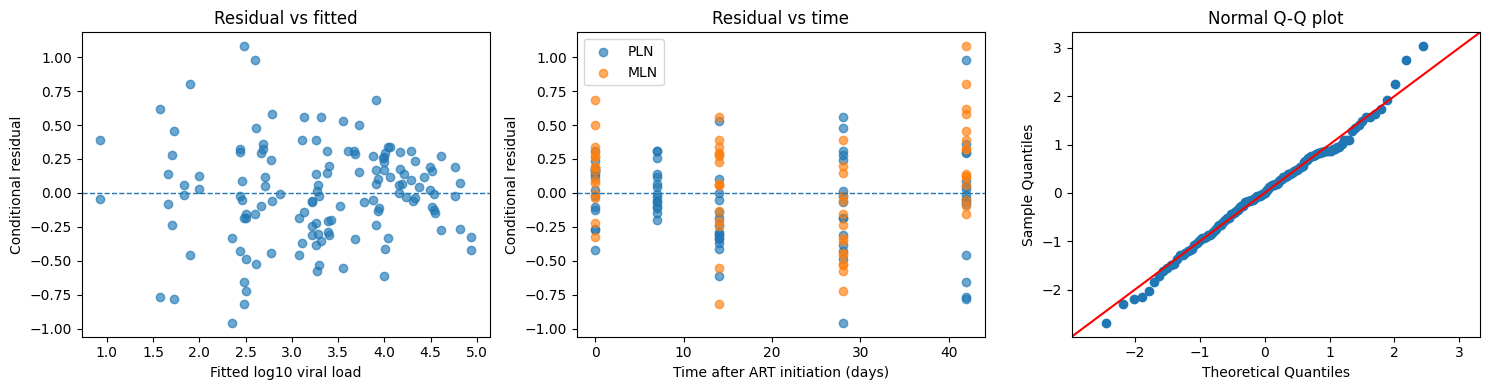

Conditional residual SD = 0.356


In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

plot_df = df.copy()
plot_df["fitted_cond"] = fit_eq1.fittedvalues
plot_df["resid_cond"] = plot_df["v_log10"] - plot_df["fitted_cond"]
sigma_hat = plot_df["resid_cond"].std(ddof=1)
plot_df["resid_cond_std"] = plot_df["resid_cond"] / sigma_hat

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(plot_df["fitted_cond"], plot_df["resid_cond"], alpha=0.65)
axes[0].axhline(0.0, linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted log10 viral load")
axes[0].set_ylabel("Conditional residual")
axes[0].set_title("Residual vs fitted")

for tissue in ["PLN", "MLN"]:
    sub = plot_df[plot_df["tissue"] == tissue]
    axes[1].scatter(sub["time_days"], sub["resid_cond"], alpha=0.65, label=tissue)
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_xlabel("Time after ART initiation (days)")
axes[1].set_ylabel("Conditional residual")
axes[1].set_title("Residual vs time")
axes[1].legend()

qqplot(plot_df["resid_cond_std"], line="45", ax=axes[2])
axes[2].set_title("Normal Q-Q plot")

fig.tight_layout()
plt.show()

print(f"Conditional residual SD = {sigma_hat:.3f}")


## Figure 4B

This cell generates the manuscript's model-based decay panel: individual animal trajectories for PLN (solid) and MLN (dotted), fixed-effect mean trajectories from Equation (1), and bands showing ±1 residual SD around the fitted mean on the log10 scale.


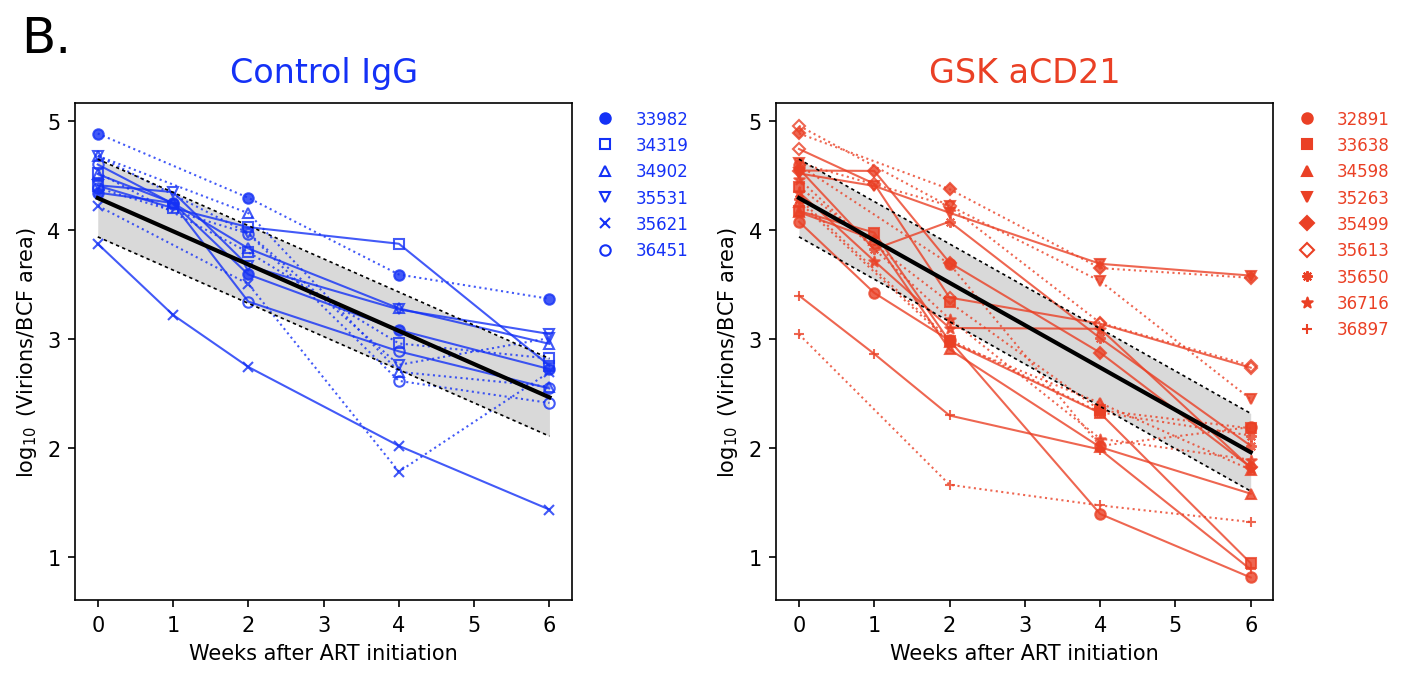

Saved figure4B_joint_PLN_MLN_LME_v5.png and figure4B_joint_PLN_MLN_LME_v5.pdf


In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D, MarkerStyle

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.transparent": False,
})

CHI_BLUE = "#1431F6"
CHI_RED = "#EA4025"

control_marker_map = {
    "33982": ("o", True),
    "34319": ("s", False),
    "34902": ("^", False),
    "35531": ("v", False),
    "35621": ("x", True),
    "36451": ("o", False),
}

treated_marker_map = {
    "32891": ("o", True),
    "33638": ("s", True),
    "34598": ("^", True),
    "35263": ("v", True),
    "35499": ("D", True),
    "35613": ("D", False),
    "35650": (MarkerStyle((8, 2, 0)), True),
    "36716": (r"$\bigstar$", True),
    "36897": ("+", True),
}

beta0 = fe["Intercept"]
c_C = fe["scaled_time"]
Delta_c = fe["scaled_time:treated_flag"]

days_grid = np.linspace(df["time_days"].min(), df["time_days"].max(), 200)
x_grid = -days_grid / LN10

def fixed_pred(x, treated_flag):
    return beta0 + c_C * x + Delta_c * x * treated_flag

v_control = fixed_pred(x_grid, 0.0)
v_treated = fixed_pred(x_grid, 1.0)

sigma = (df["v_log10"] - fit_eq1.fittedvalues).std(ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.8), sharey=True)
fig.subplots_adjust(left=0.12, right=0.88, top=0.88, bottom=0.18, wspace=0.45)

def marker_colors(marker, filled, color):
    if isinstance(marker, str) and marker in {"x", "+", "*"}:
        return "none", color
    return (color if filled else "none"), color

def plot_panel(ax, arm_label, ids, marker_map, color, v_line, title):
    sub = df[df["treatment"] == arm_label]
    for aid in ids:
        aid_str = str(aid)
        sub_a = sub[sub["animal_id"] == aid_str]
        marker, filled = marker_map[aid_str]
        for tissue, linestyle in [("PLN", "-"), ("MLN", ":")]:
            sub_at = sub_a[sub_a["tissue"] == tissue]
            if sub_at.empty:
                continue
            markersize = 3.8 if (isinstance(marker, str) and marker == "D") else 5.0
            markerfacecolor, markeredgecolor = marker_colors(marker, filled, color)
            ax.plot(
                sub_at["time_weeks"], sub_at["v_log10"],
                linestyle=linestyle,
                marker=marker,
                markersize=markersize,
                markerfacecolor=markerfacecolor,
                markeredgecolor=markeredgecolor,
                color=color,
                linewidth=1.0,
                alpha=0.8,
            )

    lower = v_line - sigma
    upper = v_line + sigma
    ax.fill_between(days_grid / 7.0, lower, upper, color="0.0", alpha=0.15, linewidth=0, zorder=0)
    ax.plot(days_grid / 7.0, v_line, color="k", linewidth=2.0, zorder=2)
    ax.plot(days_grid / 7.0, lower, color="0.0", lw=0.8, linestyle=(0, (2, 2)), zorder=2)
    ax.plot(days_grid / 7.0, upper, color="0.0", lw=0.8, linestyle=(0, (2, 2)), zorder=2)

    ax.set_title(title, fontsize=16, pad=10, color=color)
    ax.set_xlabel("Weeks after ART initiation")
    ax.set_ylabel(r"$\log_{10}$ (Virions/BCF area)")
    ax.tick_params(axis="y", which="both", labelleft=True)
    ax.set_box_aspect(1)

plot_panel(axes[0], "ART only", CONTROL_IDS, control_marker_map, CHI_BLUE, v_control, "Control IgG")
plot_panel(axes[1], "ART + anti-CD21", TREATED_IDS, treated_marker_map, CHI_RED, v_treated, "GSK aCD21")

fig.text(0.02, 0.98, "B.", fontsize=24, fontweight="normal", ha="left", va="top")

for ax, ids, marker_map, color in [
    (axes[0], CONTROL_IDS, control_marker_map, CHI_BLUE),
    (axes[1], TREATED_IDS, treated_marker_map, CHI_RED),
]:
    handles = []
    for aid in ids:
        aid_str = str(aid)
        marker, filled = marker_map[aid_str]
        markerfacecolor, markeredgecolor = marker_colors(marker, filled, color)
        handles.append(Line2D(
            [0], [0], marker=marker, linestyle="", markersize=5.0,
            markerfacecolor=markerfacecolor, markeredgecolor=markeredgecolor,
            color=color, label=aid_str,
        ))
    legend = ax.legend(
        handles=handles, frameon=False, fontsize=8,
        loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
    )
    for text in legend.get_texts():
        text.set_color(color)

fig.tight_layout()

png_name = "figure4B_joint_PLN_MLN_LME_v5.png"
pdf_name = "figure4B_joint_PLN_MLN_LME_v5.pdf"
fig.savefig(png_name, dpi=600, bbox_inches="tight")
fig.savefig(pdf_name, bbox_inches="tight")
plt.show()
print(f"Saved {png_name} and {pdf_name}")


## Robustness Checks

The manuscript reports two compact robustness analyses: per-animal OLS slopes compared by Welch's t-test, and a GEE model with robust standard errors clustered by animal.


In [9]:
import statsmodels.api as sm

rows = []
for aid, sub in df.groupby("animal_id"):
    X = sm.add_constant(sub["scaled_time"].values)
    y = sub["v_log10"].values
    ols_res = sm.OLS(y, X).fit()
    rows.append({
        "animal_id": aid,
        "treatment": sub["treatment"].iloc[0],
        "n_obs": len(sub),
        "slope_scaled_time": ols_res.params[1],
    })

slopes_df = pd.DataFrame(rows)
display(slopes_df)

ctl_slopes = slopes_df.loc[slopes_df["treatment"] == "ART only", "slope_scaled_time"].values
trt_slopes = slopes_df.loc[slopes_df["treatment"] == "ART + anti-CD21", "slope_scaled_time"].values

t_stat, p_two_sided = stats.ttest_ind(trt_slopes, ctl_slopes, equal_var=False)
p_one_sided = p_two_sided / 2.0 if t_stat > 0 else 1.0 - p_two_sided / 2.0

m_trt, m_ctl = trt_slopes.mean(), ctl_slopes.mean()
s_trt, s_ctl = trt_slopes.std(ddof=1), ctl_slopes.std(ddof=1)
n_trt, n_ctl = len(trt_slopes), len(ctl_slopes)

se_diff = np.sqrt((s_trt**2 / n_trt) + (s_ctl**2 / n_ctl))
df_welch = ((s_trt**2 / n_trt) + (s_ctl**2 / n_ctl))**2 / (
    ((s_trt**2 / n_trt)**2 / (n_trt - 1)) +
    ((s_ctl**2 / n_ctl)**2 / (n_ctl - 1))
)
crit = stats.t.ppf(0.975, df_welch)
diff = m_trt - m_ctl
ci_low, ci_high = diff - crit * se_diff, diff + crit * se_diff

print("Per-animal slopes (v_log10 ~ scaled_time):")
print(f"  Control: n = {n_ctl}, mean = {m_ctl:.4f}, SD = {s_ctl:.4f}")
print(f"  Treated: n = {n_trt}, mean = {m_trt:.4f}, SD = {s_trt:.4f}")
print(f"  Difference treated - control = {diff:.4f}")
print(f"  95% CI = ({ci_low:.4f}, {ci_high:.4f})")
print(f"  Welch t = {t_stat:.3f}, df = {df_welch:.1f}, two-sided p = {p_two_sided:.4g}")
print(f"  one-sided p for treated > control = {p_one_sided:.4g}")


,animal_id,treatment,n_obs,slope_scaled_time
0,32891,ART + anti-CD21,9,0.162451
1,33638,ART + anti-CD21,9,0.151150
2,33982,ART only,9,0.087109
3,34319,ART only,9,0.091001
4,34598,ART + anti-CD21,9,0.140685
5,34902,ART only,9,0.107316
6,35263,ART + anti-CD21,9,0.086598
7,35499,ART + anti-CD21,9,0.115038
8,35531,ART only,9,0.090961
9,35613,ART + anti-CD21,9,0.115768


Per-animal slopes (v_log10 ~ scaled_time):
  Control: n = 6, mean = 0.1012, SD = 0.0131
  Treated: n = 9, mean = 0.1272, SD = 0.0230
  Difference treated - control = 0.0260
  95% CI = (0.0058, 0.0462)
  Welch t = 2.783, df = 12.8, two-sided p = 0.0157
  one-sided p for treated > control = 0.007849


In [10]:
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable

gee_model = smf.gee(
    formula="v_log10 ~ scaled_time + scaled_time:treated_flag",
    groups="animal_id",
    data=df,
    family=Gaussian(),
    cov_struct=Exchangeable(),
)

gee_res = gee_model.fit()
print(gee_res.summary())

Delta_gee = gee_res.params["scaled_time:treated_flag"]
se_gee = gee_res.bse["scaled_time:treated_flag"]
z_gee = Delta_gee / se_gee
p_two_sided_gee = gee_res.pvalues["scaled_time:treated_flag"]
p_one_sided_gee = p_two_sided_gee / 2.0 if Delta_gee > 0 else 1.0 - p_two_sided_gee / 2.0

print("\nGEE estimate for treatment effect on decay:")
print(f"  Delta_gee = {Delta_gee:.4f} (SE = {se_gee:.4f}, z = {z_gee:.3f})")
print(f"  two-sided p = {p_two_sided_gee:.4g}")
print(f"  one-sided p for Delta_gee > 0 = {p_one_sided_gee:.4g}")


                               GEE Regression Results                              
Dep. Variable:                     v_log10   No. Observations:                  135
Model:                                 GEE   No. clusters:                       15
Method:                        Generalized   Min. cluster size:                   9
                      Estimating Equations   Max. cluster size:                   9
Family:                           Gaussian   Mean cluster size:                 9.0
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 05 Jun 2026   Scale:                           0.354
Covariance type:                    robust   Time:                         15:44:17
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.2950      0.107     40.110 

## Summary

The primary LME model estimates a positive treatment effect on the decay constant. BIC favors the treatment-specific model over the single-rate null model and does not favor adding tissue-specific fixed effects. The per-animal slope and GEE robustness checks produce treatment effects of similar magnitude and significance.
